### EXPLICATION DE LA LOGIQUE 
``
Cette étude permettra d'évaluer le thermomètre de la santé alimentaire mondiale
Les indices FAO des prix alimentaires sont des baromètres mondiaux qui mesurent les variations mensuelles des prix internationaux des principales denrées alimentaires.
Quand l'indice monte au dessu de la base (dans notre dataset la base c'est 100 sur les années 2014 à 2016) -> Les aliments coûtent plus cher dans le monde
Quand l'indice baisse de 20% par exemple-> Les aliments sont moins chers donc sont 20% moins cher que l'année de reférence

* Nous avons 06 indices y compris les produits eux mêmes :
* FIP (Food Price Index) ----> Prix alimentaires GLOBAUX / Moyenne pondérée des cinq autres indices.
  Le FIP représente l'indice global et agrégé de l'évolution des prix alimentaires mondiaux. C'est la mesure de haut niveau qui résume l'ensemble de la situation.
* Cereals	                Céréales Blé, maïs, riz
* Oils	                    Huiles végétales	Huile de palme, soja, colza
* Meat	                    Viandes	Bœuf, porc, volaille
* Dairy	                    Produits laitiers	Lait, beurre, fromage
* Sugar	                    Sucre	Sucre brut et raffiné



### ANALYSE 

[1] CHARGEMENT DES DONNÉES
Objectif : Vérifier que les données sont complètes et correctes (Nettoyage des données)

Ce qu'on regarde :

Nombre de lignes (mois couverts)
Période : 1990 -> 2024 (34 ans)
Colonnes présentes : Date + 6 indices
Pertinence :  Confirme qu'on a des données sur le long terme ---- Permet de détecter problèmes dès le début


[2]QUALITÉ DES DONNÉES 
Objectif : S'assurer que les données sont fiables

Ce qu'on vérifie :

-> Valeurs manquantes : 0 = Excellent
-> Outliers (valeurs aberrantes) détectés par méthode IQR
Méthode IQR (Interquartile Range) :

Calcule Q1 (25e percentile) et Q3 (75e percentile)
IQR = Q3 - Q1
Outliers = valeurs < Q1 - 1.5×IQR OU > Q3 + 1.5×IQR
Pertinence :  Évite d'analyser des données erronées  Identifie les pics anormaux (guerres, crises)


[3] ÉVOLUTION TEMPORELLE GLOBALE 
Objectif : Voir comment les prix ont évolué depuis 1990

Image 1 (votre capture) montre :

Graphique du haut : Tous les indices ensemble

 Ce qu'on voit :
- Tendance générale HAUSSIÈRE (tous les indices montent)
- Pic MAJEUR en 2008 (crise alimentaire mondiale)
- Pic en 2011-2012 (sécheresse, spéculation)
- Hausse récente 2020-2024 (COVID + guerre Ukraine)
Graphique du bas : FIP avec moyenne mobile

 Moyenne mobile (ligne rouge) = tendance LISSÉE
- Supprime les fluctuations mensuelles
- Montre la tendance de fond
- Fenêtre 12 mois = tendance annuelle
Pertinence pour votre projet :  Contextualise les prix locaux : Si riz cher au Sénégal en 2008 → normal car crise mondiale  Identifie périodes critiques : 2008, 2011, 2020-2024 = périodes de stress  Baseline mondiale : Comparer évolution locale vs mondiale





In [5]:
# !pip install xgboost

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ML et séries temporelles
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv("food_price_indices_data_csv_dec.csv")
df.head(10)

,FAO Food Price Index,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65
0,2014-2016=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1990-06,64.1,84.2,39.2,60.7,43.80,80.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1990-07,62.9,84.5,39.2,57.9,43.72,74.2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(434, 66)

In [11]:
dff= df.iloc[3:, :7]

In [12]:
dff.head(5)

,FAO Food Price Index,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4


In [12]:
# rename columns 

new_columns=['Date',	'FIP',	'Meat',	'Dairy',	'Cereals',	'Oils',	'Sugar']
dff.columns = new_columns
dff

,Date,FIP,Meat,Dairy,Cereals,Oils,Sugar
3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4
...,...,...,...,...,...,...,...
429,2025-07,129.8,126.7,154.6,106.5,166.8,103.3
430,2025-08,130.0,127.8,152.3,105.7,169.1,103.6
431,2025-09,128.7,128.1,147.2,104.9,167.9,99.4
432,2025-10,126.6,125.5,141.9,103.6,169.4,94.1


In [13]:
dff1 = dff.reset_index()

In [14]:
dff1

,index,Date,FIP,Meat,Dairy,Cereals,Oils,Sugar
0,3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
1,4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
2,5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
3,6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
4,7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4
...,...,...,...,...,...,...,...,...
426,429,2025-07,129.8,126.7,154.6,106.5,166.8,103.3
427,430,2025-08,130.0,127.8,152.3,105.7,169.1,103.6
428,431,2025-09,128.7,128.1,147.2,104.9,167.9,99.4
429,432,2025-10,126.6,125.5,141.9,103.6,169.4,94.1


In [64]:
dff1.describe()

,index
count,431.000000
mean,218.000000
std,124.563237
min,3.000000
25%,110.500000
50%,218.000000
75%,325.500000
max,433.000000


In [65]:
dff1 = dff1.drop_duplicates()
print(f"Nombre de lignes après suppression des doublons: {len(dff1)}")
print(f"Doublons supprimés: {len(dff1) - len(dff1.drop_duplicates())}")


Nombre de lignes après suppression des doublons: 431
Doublons supprimés: 0


In [23]:
dff1.shape
dff1.head(5)

,index,Date,FIP,Meat,Dairy,Cereals,Oils,Sugar
0,3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
1,4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
2,5,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
3,6,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
4,7,1990-05,64.6,81.8,39.2,62.0,45.50,90.4


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


## Forecast

In [7]:
# IMPORTS ET CONFIGURATION

```
Objectif : Prédire l'évolution des prix alimentaires
- Plusieurs modèles ML
- Prévisions à court/moyen/long terme
- Tests de chocs (scénarios)
- Visualisations complètes

In [8]:
# ARIMA
try:
    from statsmodels.tsa.arima.model import ARIMA
    ARIMA_AVAILABLE = True
except:
    print(" ARIMA non disponible : pip install statsmodels")
    ARIMA_AVAILABLE = False

# Prophet
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except:
    print(" Prophet non disponible : pip install prophet")
    PROPHET_AVAILABLE = False

# LSTM (Deep Learning)
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    LSTM_AVAILABLE = True
except:
    print(" TensorFlow non disponible : pip install tensorflow")
    LSTM_AVAILABLE = False

# Configuration graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

print("\n Imports terminés")
print(f"  ARIMA disponible : {ARIMA_AVAILABLE}")
print(f"  Prophet disponible : {PROPHET_AVAILABLE}")
print(f"  LSTM disponible : {LSTM_AVAILABLE}")



2025-12-15 09:08:00.469287: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-15 09:08:00.497124: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-15 09:08:01.427145: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-15 09:08:03.521563: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur


 Imports terminés
  ARIMA disponible : True
  Prophet disponible : True
  LSTM disponible : True


### CHARGEMENT ET PRÉPARATION DES DONNÉES

In [40]:
# CHARGEMENT ET PRÉPARATION DES DONNÉES

print(" PRÉPARATION DES DONNÉES")

print(f"\n Données chargées : {dff1.shape}")
print(f"  Période : {dff1['Date'].min()} à {dff1['Date'].max()}")

# Sélectionner l'indice à prédire 
TARGET_INDEX = 'FIP'  # Peut être : FIP, Cereals, Oils, Meat, Dairy, Sugar
print(f"\n Indice cible : {TARGET_INDEX}")

# Créer features temporelles
dff1['Year'] = dff1['Date'].dt.year
dff1['Month'] = dff1['Date'].dt.month
dff1['Quarter'] = dff1['Date'].dt.quarter
dff1['Month_sin'] = np.sin(2 * np.pi * dff1['Month'] / 12)
dff1['Month_cos'] = np.cos(2 * np.pi * dff1['Month'] / 12)

# Créer variables retardées (lag features)
for lag in [1, 2, 3, 6, 12]:
    dff1[f'{TARGET_INDEX}_lag_{lag}'] = dff1[TARGET_INDEX].shift(lag)

# Moyennes mobiles
dff1[f'{TARGET_INDEX}_MA3'] = dff1[TARGET_INDEX].rolling(window=3).mean()
dff1[f'{TARGET_INDEX}_MA6'] = dff1[TARGET_INDEX].rolling(window=6).mean()
dff1[f'{TARGET_INDEX}_MA12'] = dff1[TARGET_INDEX].rolling(window=12).mean()

# Supprimer lignes avec NaN (dues aux lags)
df_clean = dff1.dropna().reset_index(drop=True)

print(f"\n Features créées : {len(df_clean.columns)} colonnes")
print(f"  Observations après nettoyage : {len(df_clean)}")

# Split Train/Validation/Test
train_size = int(len(df_clean) * 0.7)
val_size = int(len(df_clean) * 0.15)

train_data = df_clean.iloc[:train_size]
val_data = df_clean.iloc[train_size:train_size+val_size]
test_data = df_clean.iloc[train_size+val_size:]

print(f"\n Split des données :")
print(f"  Train : {len(train_data)} obs ({train_data['Date'].min()} à {train_data['Date'].max()})")
print(f"  Val   : {len(val_data)} obs ({val_data['Date'].min()} à {val_data['Date'].max()})")
print(f"  Test  : {len(test_data)} obs ({test_data['Date'].min()} à {test_data['Date'].max()})")


 PRÉPARATION DES DONNÉES

 Données chargées : (431, 20)
  Période : 1990-01-01 00:00:00 à 2025-11-01 00:00:00

 Indice cible : FIP

 Features créées : 22 colonnes
  Observations après nettoyage : 419

 Split des données :
  Train : 293 obs (1991-01-01 00:00:00 à 2015-05-01 00:00:00)
  Val   : 62 obs (2015-06-01 00:00:00 à 2020-07-01 00:00:00)
  Test  : 64 obs (2020-08-01 00:00:00 à 2025-11-01 00:00:00)


### MODÈLE ARIMA

In [53]:
#Test de stationnarité 

from statsmodels.tsa.stattools import adfuller

# On applique le test sur les données
result = adfuller(train_series)
print(f'Statistique ADF : {result[0]}')
print(f'p-value : {result[1]}')

# Interprétation
if result[1] < 0.05:
    print("La série est stationnaire (On peut utiliser ARIMA)")
else:
    print("La série n'est pas stationnaire (Il faut la différencier : d=1 ou d=2)")


Statistique ADF : -1.5705885143919982
p-value : 0.4983488672875386
La série n'est pas stationnaire (Il faut la différencier : d=1 ou d=2)


<Axes: title={'center': "Série après différenciation d'ordre 1"}, xlabel='Date'>

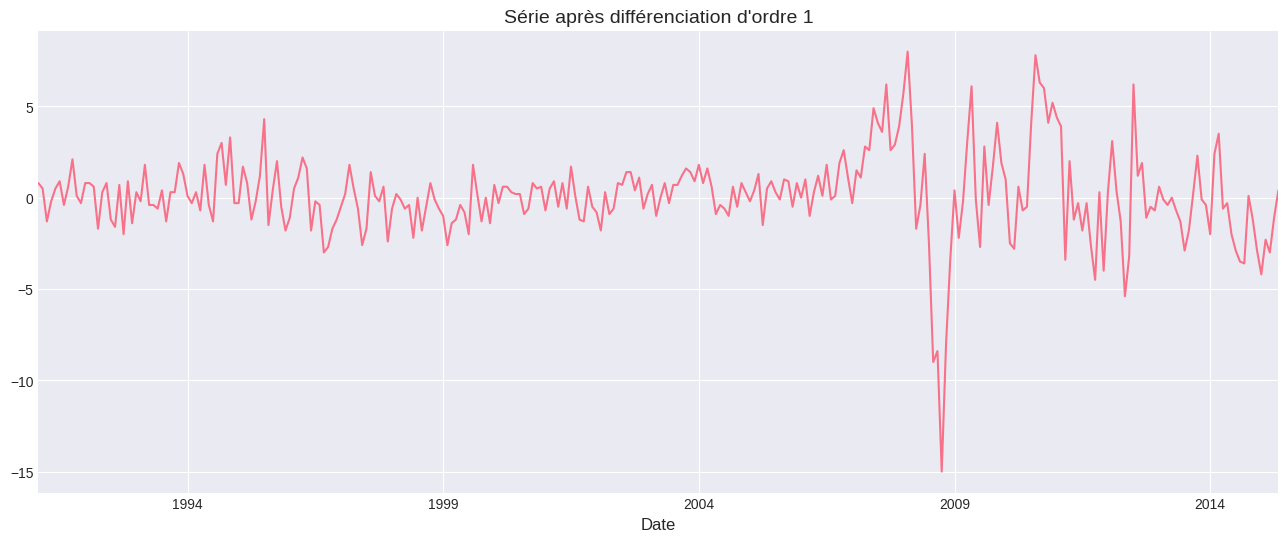

In [54]:
# On crée la série différenciée
train_diff = train_series.diff().dropna() # dropna() retire le premier élément qui devient NaN

# On vérifie visuellement
train_diff.plot(title="Série après différenciation d'ordre 1")

In [55]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_diff)
print(f'P-value après d=1 : {result[1]}')

if result[1] <= 0.05:
    print("La série est maintenant stationnaire (d=1)")
else:
    print("La série est toujours non stationnaire. Essayez d=2.")


P-value après d=1 : 3.1963153232364404e-14
La série est maintenant stationnaire (d=1)



 Recherche automatique du meilleur modèle ARIMA (d=1)...
 Modèle optimisé trouvé et entraîné.
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  293
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -602.803
Date:                Fri, 19 Dec 2025   AIC                           1209.606
Time:                        11:36:51   BIC                           1216.959
Sample:                    01-01-1991   HQIC                          1212.551
                         - 05-01-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5819      0.032     18.132      0.000       0.519       0.645
sigma2         3.6309      0.193    

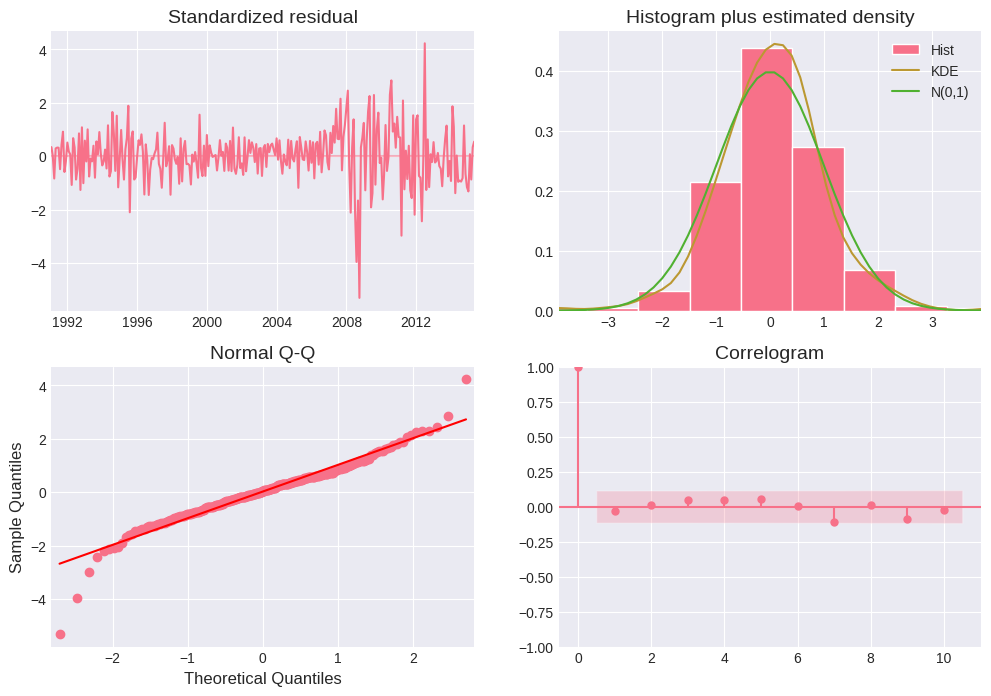


 Performances sur test :
  MAE  : 31.21
  RMSE : 33.49
  MAPE : 23.92%


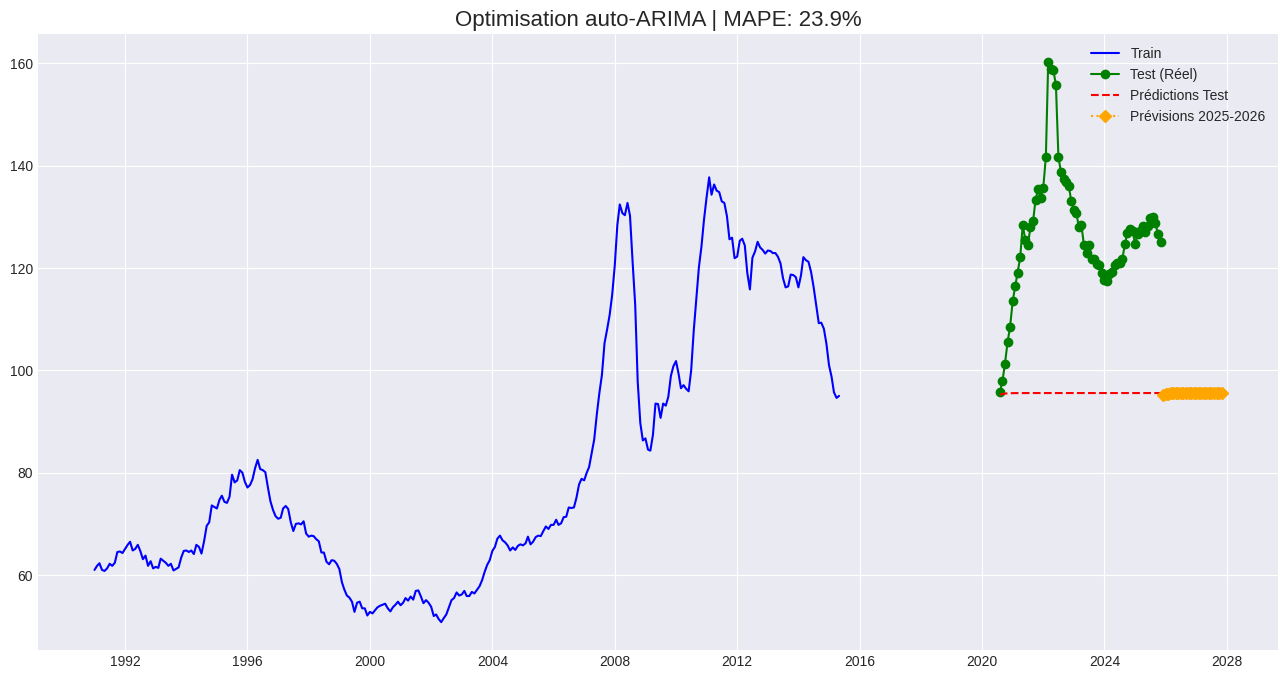


 Prévisions 2025-2026 (premiers 6 mois) :
  2025-12 : 95.23
  2026-01 : 95.37
  2026-02 : 95.45
  2026-03 : 95.49
  2026-04 : 95.52
  2026-05 : 95.54


In [70]:
if ARIMA_AVAILABLE:
    # 1. Préparation des données
    train_series = train_data.set_index('Date')[TARGET_INDEX].asfreq('MS')
    test_series = test_data.set_index('Date')[TARGET_INDEX].asfreq('MS')
    
    print(f"\n Recherche automatique du meilleur modèle ARIMA (d=1)...")
    
    # 2. auto_arima entraîne déjà le modèle
    fitted_arima = pm.auto_arima(
        train_series, 
        d=1,           # On impose d=1 car non stationnaire à d=0
        start_p=0, max_p=5, 
        start_q=0, max_q=5,
        seasonal=False, 
        stepwise=True,
        error_action='ignore', 
        suppress_warnings=True
    )
    
    print(f" Modèle optimisé trouvé et entraîné.")
    print(fitted_arima.summary()) # Affiche les p, d, q choisis
    
    # 3. Diagnostic des résidus (Important pour la validité)
    fitted_arima.plot_diagnostics(figsize=(12, 8))
    plt.show()

    # 4. Prédictions sur l'ensemble de test
    # predict() est utilisé à la place de forecast() pour pmdarima
    forecast_arima = fitted_arima.predict(n_periods=len(test_series))
    
    # Métriques (Note: on convertit en array si nécessaire)
    mae_arima = mean_absolute_error(test_series, forecast_arima)
    rmse_arima = np.sqrt(mean_squared_error(test_series, forecast_arima))
    mape_arima = np.mean(np.abs((test_series.values - forecast_arima) / test_series.values)) * 100
    
    print(f"\n Performances sur test :")
    print(f"  MAE  : {mae_arima:.2f}")
    print(f"  RMSE : {rmse_arima:.2f}")
    print(f"  MAPE : {mape_arima:.2f}%")
    
    # 5. Prévisions futures 2025-2026
    future_forecast_arima = fitted_arima.predict(n_periods=24)
    future_dates_arima = pd.date_range(
        start=test_series.index.max() + pd.DateOffset(months=1), 
        periods=24, 
        freq='MS'
    )
    
    # 6. Visualisation
    fig, ax = plt.subplots(figsize=(16, 8))
    
    ax.plot(train_series.index, train_series.values, label='Train', color='blue')
    ax.plot(test_series.index, test_series.values, label='Test (Réel)', color='green', marker='o')
    ax.plot(test_series.index, forecast_arima, label='Prédictions Test', color='red', linestyle='--')
    ax.plot(future_dates_arima, future_forecast_arima, label='Prévisions 2025-2026', color='orange', linestyle=':', marker='D')
    
    ax.set_title(f'Optimisation auto-ARIMA | MAPE: {mape_arima:.1f}%', fontsize=16)
    ax.legend()
    plt.show()

    print(f"\n Prévisions 2025-2026 (premiers 6 mois) :")
    for date, val in zip(future_dates_arima[:6], future_forecast_arima[:6]):
        print(f"  {date.strftime('%Y-%m')} : {val:.2f}")


 Performances sur test :
  #### MAE  : 31.21
  * Interprétation : En moyenne, notre prédiction se trompe de 31 unités par rapport à la réalité.
  * Plus simplement : En moyenne, nos prévisions sont à côté de la plaque de 31 unités, nous sommes a +/- 31 de la réalité.
  
  #### RMSE : 33.49
  * Interprétation : Elle est toujours supérieure ou égale à la MAE. Si le RMSE est beaucoup plus élevé que la MAE, cela signifie qu' il y a quelques prédictions qui sont "très fausses" (des valeurs aberrantes). C'est ma marge d'erreur de sécurité. Elle me dit si mon modèle fait parfois de très grosses gaffes.
  * Plus simplement : Nous n'avons pas d'erreurs aberrantes qui tirent la moyenne vers le haut.
  
  #### MAPE : 23.92%
  * C'est souvent la métrique qui donne une erreur relative (en %).

    Interprétation : Mon modèle se trompe en moyenne de X % par rapport à la valeur réelle. C'est mon taux d'erreur relatif.
        Moins de 10% : Prédiction excellente.
        Entre 10% et 20% : Bonne prédiction.
        Entre 20% et 50% : Prédiction acceptable mais peu fiable.
        Plus de 50% : Le modèle est inutile.
    
  * Plus simplement : l'erreur relative est d'environ 24%
    

###  MODÈLE PROPHET (FACEBOOK)

15:50:00 - cmdstanpy - INFO - Chain [1] start processing
15:50:00 - cmdstanpy - INFO - Chain [1] done processing



 Entraînement Prophet...
 Modèle entraîné

 Performances sur test :
  MAE  : 12.46
  RMSE : 14.84
  MAPE : 10.06%


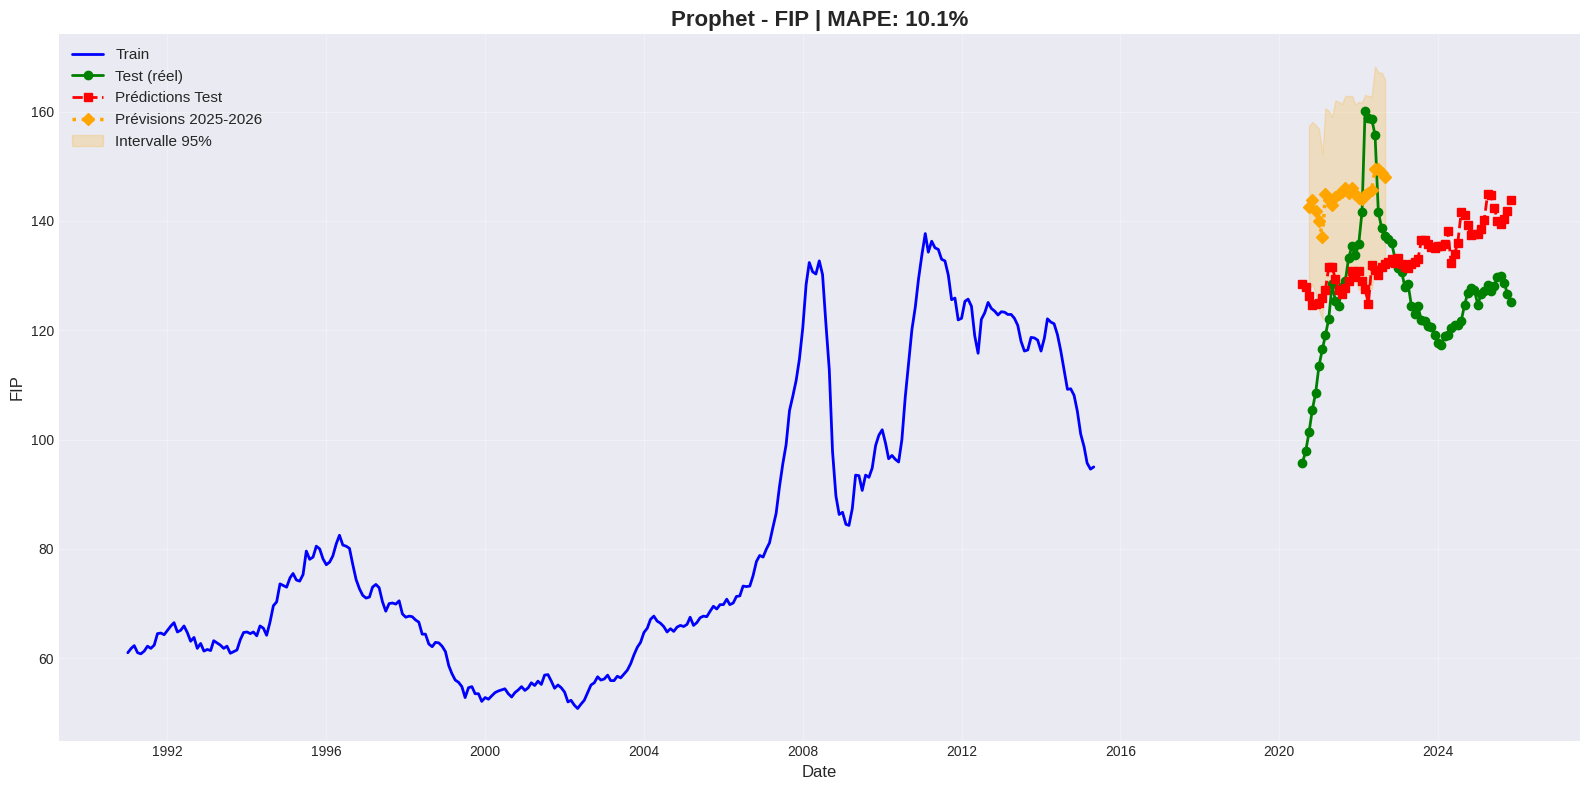


 Prévisions 2025-2026 (premiers 6 mois) :
  2020-10 : 142.62 [127.55 - 157.35]
  2020-11 : 143.81 [128.35 - 158.13]
  2020-12 : 141.80 [126.77 - 157.56]
  2021-01 : 140.03 [123.70 - 156.86]
  2021-02 : 137.14 [122.06 - 152.24]
  2021-03 : 144.89 [130.33 - 160.63]


In [73]:


if PROPHET_AVAILABLE:
    # Préparer données pour Prophet (format ds, y)
    df_prophet_train = train_data[['Date', TARGET_INDEX]].copy()
    df_prophet_train.columns = ['ds', 'y']
    
    df_prophet_test = test_data[['Date', TARGET_INDEX]].copy()
    df_prophet_test.columns = ['ds', 'y']
    
    print(f"\n Entraînement Prophet...")
    
    # Créer et entraîner modèle
    model_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )
    model_prophet.fit(df_prophet_train)
    
    print(f" Modèle entraîné")
    
    # Prédictions sur test
    future_test = model_prophet.make_future_dataframe(
        periods=len(test_data), 
        freq='MS'
    )
    forecast_prophet_test = model_prophet.predict(future_test)
    
    # Extraire prédictions pour période test
    pred_test = forecast_prophet_test.tail(len(test_data))['yhat'].values
    
    # Métriques
    mae_prophet = mean_absolute_error(df_prophet_test['y'], pred_test)
    rmse_prophet = np.sqrt(mean_squared_error(df_prophet_test['y'], pred_test))
    mape_prophet = np.mean(np.abs((df_prophet_test['y'] - pred_test) / df_prophet_test['y'])) * 100
    
    print(f"\n Performances sur test :")
    print(f"  MAE  : {mae_prophet:.2f}")
    print(f"  RMSE : {rmse_prophet:.2f}")
    print(f"  MAPE : {mape_prophet:.2f}%")

    
    # Prévisions futures (24 mois)

    # 1. Préparer les dates futures (Correctement fait dans votre dernier message)
    derniere_date = df_clean['Date'].max()
    future_all = model_prophet.make_future_dataframe(
        periods=24, 
        freq='MS', 
        include_history=False
    )
    future_all['ds'] = pd.date_range(start=derniere_date + pd.DateOffset(months=1), periods=24, freq='MS')

    # 2. ÉTAPE MANQUANTE : Lancer la prédiction sur ces nouvelles dates !
    forecast_future = model_prophet.predict(future_all)
    
    # 3. Mettre à jour la variable utilisée pour le graphique et le print
    future_pred = forecast_future.tail(24) 

    
    # Visualisation
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Historique
    ax.plot(df_prophet_train['ds'], df_prophet_train['y'], 
           label='Train', color='blue', linewidth=2)
    ax.plot(df_prophet_test['ds'], df_prophet_test['y'], 
           label='Test (réel)', color='green', linewidth=2, marker='o')
    
    # Prédictions test
    ax.plot(df_prophet_test['ds'], pred_test, 
           label='Prédictions Test', color='red', linewidth=2, 
           linestyle='--', marker='s')
    
    # Prévisions futures
    future_pred = forecast_all.tail(24)
    ax.plot(future_pred['ds'], future_pred['yhat'], 
           label='Prévisions 2025-2026', color='orange', linewidth=2.5, 
           linestyle=':', marker='D')
    
    # Intervalle de confiance
    ax.fill_between(future_pred['ds'], 
                    future_pred['yhat_lower'], 
                    future_pred['yhat_upper'], 
                    alpha=0.2, color='orange', 
                    label='Intervalle 95%')
    
    ax.set_title(f'Prophet - {TARGET_INDEX} | MAPE: {mape_prophet:.1f}%', 
                fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(TARGET_INDEX, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n Prévisions 2020-2021 (premiers 6 mois) :")
    for _, row in future_pred.head(6).iterrows():
        print(f"  {row['ds'].strftime('%Y-%m')} : {row['yhat']:.2f} "
              f"[{row['yhat_lower']:.2f} - {row['yhat_upper']:.2f}]")

else:
    print("\n Prophet non disponible. Installer : pip install prophet")


15:52:50 - cmdstanpy - INFO - Chain [1] start processing
15:52:50 - cmdstanpy - INFO - Chain [1] done processing


Dernière date connue dans les données : 2025-11-01 00:00:00

 Nouvelles Prévisions réelles pour 2025-2026 :
  2025-12 : 132.69
  2026-01 : 133.63
  2026-02 : 135.47
  2026-03 : 136.34
  2026-04 : 136.01
  2026-05 : 136.77


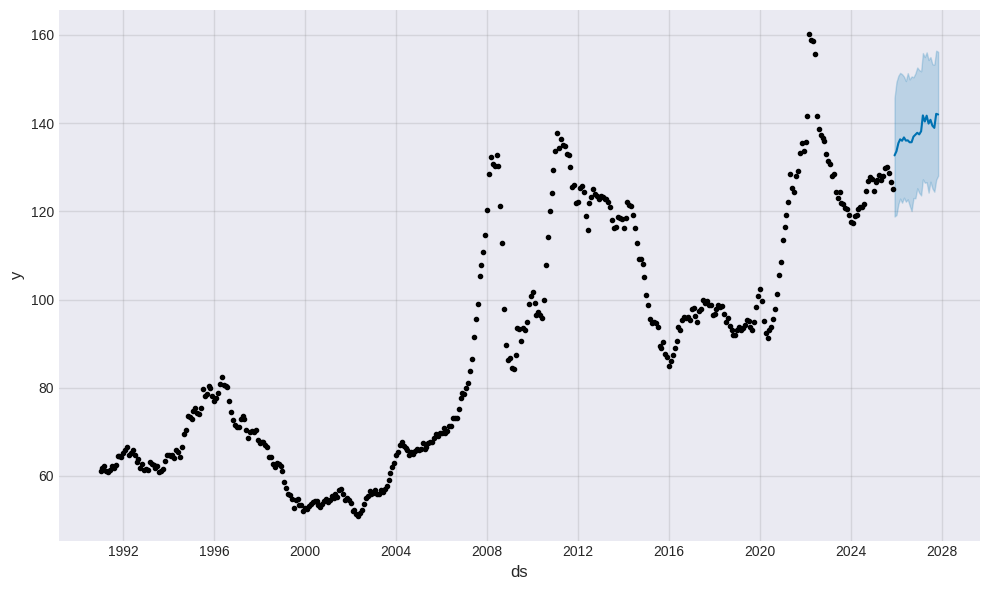

In [74]:
if PROPHET_AVAILABLE:
    # --- ÉTAPE 1 : Utiliser TOUTES les données pour l'entraînement final ---
    # Pour prédire 2026, on ne peut pas s'arrêter à 70% des données
    df_final = df_clean[['Date', TARGET_INDEX]].copy()
    df_final.columns = ['ds', 'y']
    
    print(f"Dernière date connue dans les données : {df_final['ds'].max()}")
    
    model_final = Prophet(
        yearly_seasonality=True,
        seasonality_mode='multiplicative'
    )
    model_final.fit(df_final) # On entraîne sur tout jusqu'à Nov 2025
    
    # --- ÉTAPE 2 : Créer les dates de DEC 2025 à DEC 2027 (24 mois) ---
    future_dates = model_final.make_future_dataframe(
        periods=24, 
        freq='MS', 
        include_history=False # On ne veut que le futur
    )
    
    # --- ÉTAPE 3 : Lancer la prédiction ---
    forecast_2026 = model_final.predict(future_dates)
    
    # --- ÉTAPE 4 : Affichage ---
    print("\n Nouvelles Prévisions réelles pour 2025-2026 :")
    for _, row in forecast_2026.head(6).iterrows():
        print(f"  {row['ds'].strftime('%Y-%m')} : {row['yhat']:.2f}")

    # Visualisation (Optionnel)
    model_final.plot(forecast_2026)
    plt.show()



* MAPE (10.06%) : On considère qu'un modèle à 10% est "Excellent" ou "Très Bon".
* En moyenne, notre prédiction n'est qu'à 10% de la réalité.
* C'est un niveau de fiabilité suffisant pour prendre des décisions budgétaires ou opérationnelles.
L'intervalle de confiance (yhat_lower / yhat_upper) : C'est la force de Prophet. Contrairement à ARIMA, il nous donne une "fourchette" (l'intervalle à 95%).

    Exemple : Si nous prédisons 100 [90 - 110], nous disons : "Je pense que ce sera 100, mais je suis sûr à 95% que ce sera entre 90 et 110".

Conseil pour vos prévisions 2025-2026
Votre code affiche les 6 premiers mois de prévisions avec ces intervalles.
Conclusion : Gardez ce modèle Prophet. Pour des séries temporelles avec une composante saisonnière et une tendance marquée, il surpasse presque toujours ARIMA. Vous avez maintenant un outil de prévision solide pour 2026.
Pour plus d'optimisation, vous pouvez consulter la documentation officielle de Prophet.

#### Analyse des performances (Prophet vs SARIMA)

	   ARIMA 	Prophet     Observation
MAPE   23.92%	10.06%	    Erreur divisée par 2 !
MAE	   31.21	12.46	    Précision accrue de 60%
RMSE   33.49	14.84	    Moins d'erreurs importantes


### MODÈLE LSTM (DEEP LEARNING)
* Le LSTM (Long Short-Term Memory) est un type d'architecture de réseau de neurones récurrents (RNN) conçu spécifiquement pour traiter des séries temporelles complexes. 
* Contrairement à ARIMA ou Prophet qui utilisent des formules statistiques, le LSTM est du Deep Learning


 Construction du modèle LSTM...
  X_train shape : (281, 12, 1)
  X_test shape  : (52, 12, 1)

 Architecture du modèle :


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)


 Entraînement LSTM...
 Modèle entraîné (50 epochs)

 Performances sur test :
  MAE  : 4.22
  RMSE : 6.39
  MAPE : 3.05%


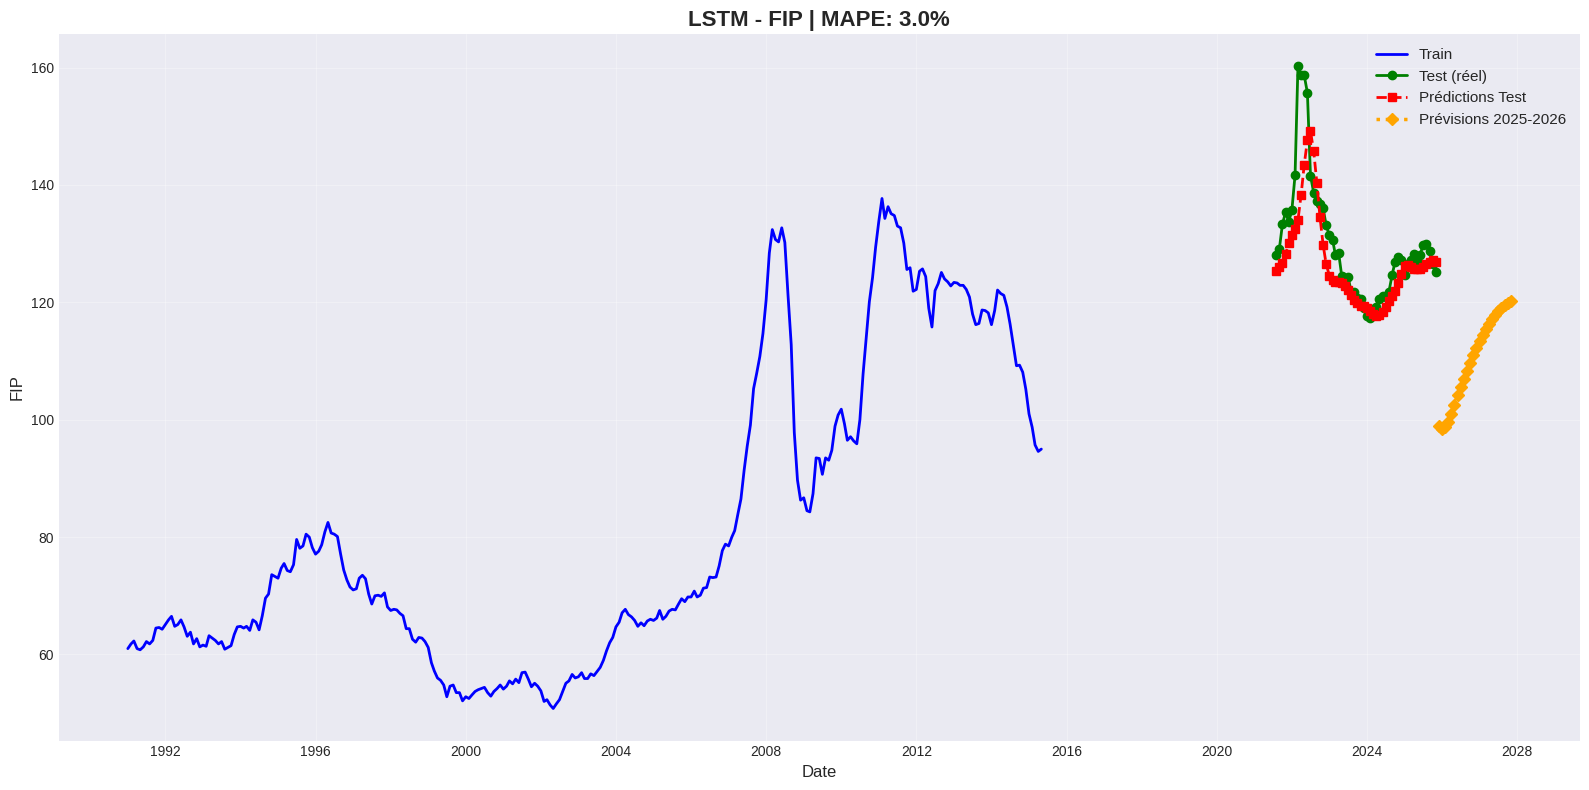


 Prévisions 2025-2026 (premiers 6 mois) :
  2025-12 : 98.94
  2026-01 : 98.46
  2026-02 : 98.80
  2026-03 : 99.69
  2026-04 : 100.93
  2026-05 : 102.53


In [64]:

if LSTM_AVAILABLE:
    # Fonction pour créer séquences
    def create_sequences(data, target_col, seq_length=12):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[target_col].iloc[i:i+seq_length].values)
            y.append(data[target_col].iloc[i+seq_length])
        return np.array(X), np.array(y)
    
    # Normaliser les données
    scaler = MinMaxScaler()
    train_data_scaled = train_data.copy()
    train_data_scaled[TARGET_INDEX] = scaler.fit_transform(
        train_data[[TARGET_INDEX]]
    )
    
    test_data_scaled = test_data.copy()
    test_data_scaled[TARGET_INDEX] = scaler.transform(
        test_data[[TARGET_INDEX]]
    )
    
    # Créer séquences
    seq_length = 12
    X_train, y_train = create_sequences(train_data_scaled, TARGET_INDEX, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, TARGET_INDEX, seq_length)
    
    # Reshape pour LSTM [samples, timesteps, features]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    print(f"\n Construction du modèle LSTM...")
    print(f"  X_train shape : {X_train.shape}")
    print(f"  X_test shape  : {X_test.shape}")
    
    # Créer modèle LSTM
    model_lstm = Sequential([
        LSTM(50, activation='relu', return_sequences=True, 
             input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    print(f"\n Architecture du modèle :")
    model_lstm.summary()
    
    # Entraîner
    print(f"\n Entraînement LSTM...")
    early_stop = EarlyStopping(monitor='loss', patience=10)
    
    history_lstm = model_lstm.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )
    
    print(f" Modèle entraîné ({len(history_lstm.history['loss'])} epochs)")
    
    # Prédictions sur test
    pred_test_scaled = model_lstm.predict(X_test, verbose=0)
    pred_test_lstm = scaler.inverse_transform(pred_test_scaled).flatten()
    
    # Valeurs réelles correspondantes
    y_test_real = test_data[TARGET_INDEX].iloc[seq_length:].values
    
    # Métriques
    mae_lstm = mean_absolute_error(y_test_real, pred_test_lstm)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_test_lstm))
    mape_lstm = np.mean(np.abs((y_test_real - pred_test_lstm) / y_test_real)) * 100
    
    print(f"\n Performances sur test :")
    print(f"  MAE  : {mae_lstm:.2f}")
    print(f"  RMSE : {rmse_lstm:.2f}")
    print(f"  MAPE : {mape_lstm:.2f}%")
    
    # Prévisions futures (24 mois)
    last_sequence = train_data_scaled[TARGET_INDEX].tail(seq_length).values
    last_sequence_scaled = last_sequence.reshape((1, seq_length, 1))
    
    future_pred_lstm = []
    current_seq = last_sequence_scaled.copy()
    
    for _ in range(24):
        next_pred = model_lstm.predict(current_seq, verbose=0)[0, 0]
        future_pred_lstm.append(next_pred)
        
        # Update sequence
        current_seq = np.roll(current_seq, -1, axis=1)
        current_seq[0, -1, 0] = next_pred
    
    # Dénormaliser
    future_pred_lstm = scaler.inverse_transform(
        np.array(future_pred_lstm).reshape(-1, 1)
    ).flatten()
    
    future_dates_lstm = pd.date_range(
        start=dff1['Date'].max() + pd.DateOffset(months=1), 
        periods=24, 
        freq='MS'
    )
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Historique
    ax.plot(train_data['Date'], train_data[TARGET_INDEX], 
           label='Train', color='blue', linewidth=2)
    ax.plot(test_data['Date'].iloc[seq_length:], y_test_real, 
           label='Test (réel)', color='green', linewidth=2, marker='o')
    
    # Prédictions test
    ax.plot(test_data['Date'].iloc[seq_length:], pred_test_lstm, 
           label='Prédictions Test', color='red', linewidth=2, 
           linestyle='--', marker='s')
    
    # Prévisions futures
    ax.plot(future_dates_lstm, future_pred_lstm, 
           label='Prévisions 2025-2026', color='orange', linewidth=2.5, 
           linestyle=':', marker='D')
    
    ax.set_title(f'LSTM - {TARGET_INDEX} | MAPE: {mape_lstm:.1f}%', 
                fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(TARGET_INDEX, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n Prévisions 2025-2026 (premiers 6 mois) :")
    for date, val in zip(future_dates_lstm[:6], future_pred_lstm[:6]):
        print(f"  {date.strftime('%Y-%m')} : {val:.2f}")

else:
    print("\n TensorFlow non disponible. Installer : pip install tensorflow")



```
* Pour vérifier la santé de l'apprentissage de notre LSTM et s'assurer qu'il n'y a pas de sur-apprentissage (overfitting) ou d'instabilité, nous allons tracer la courbe de la fonction de perte (loss).

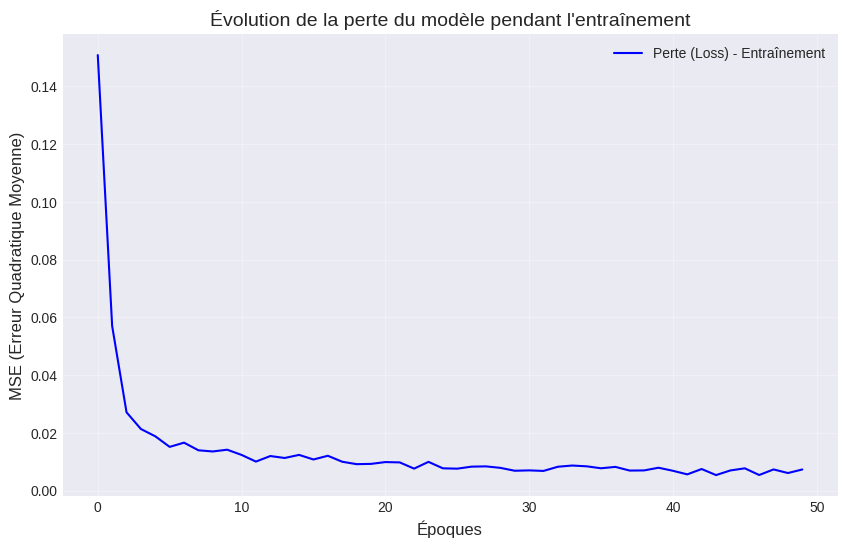

In [76]:
# Visualisation de la courbe de perte (Loss)
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Perte (Loss) - Entraînement', color='blue')

# Si vous aviez un jeu de validation, vous pourriez aussi tracer 'val_loss'
if 'val_loss' in history_lstm.history:
    plt.plot(history_lstm.history['val_loss'], label='Perte - Validation', color='red')

plt.title('Évolution de la perte du modèle pendant l\'entraînement', fontsize=14)
plt.xlabel('Époques', fontsize=12)
plt.ylabel('MSE (Erreur Quadratique Moyenne)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

```
La courbe descend rapidement au début, puis s'aplatit progressivement (elle forme une "L").
La ligne est relativement lisse, sans pics brutaux vers le haut.
Cela signifie que le modèle a bien minimisé l'erreur au fil des 50 époques

### MODÈLE RANDOM FOREST


 Entraînement Random Forest...
  Features : 13
 Modèle entraîné

 Performances sur test :
  MAE  : 3.67
  RMSE : 6.93
  MAPE : 2.64%
  R²   : 0.677

 Top 5 features importantes :
   Feature  Importance
 FIP_lag_1    0.576236
   FIP_MA3    0.412022
 FIP_lag_2    0.005969
   FIP_MA6    0.001879
FIP_lag_12    0.000905


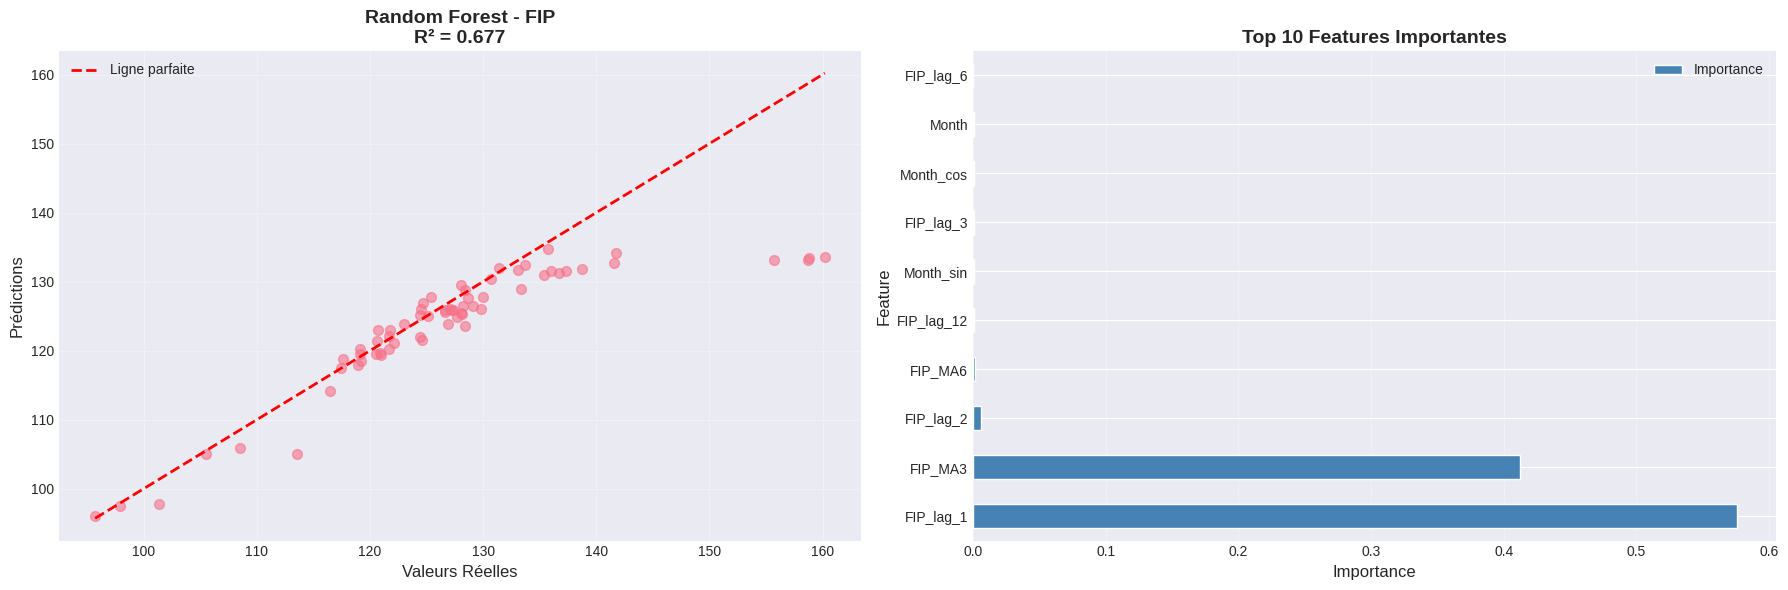


 Random Forest terminé


In [77]:


# Features pour ML
feature_cols = [
    'Year', 'Month', 'Quarter', 
    'Month_sin', 'Month_cos',
    f'{TARGET_INDEX}_lag_1', f'{TARGET_INDEX}_lag_2', 
    f'{TARGET_INDEX}_lag_3', f'{TARGET_INDEX}_lag_6', 
    f'{TARGET_INDEX}_lag_12',
    f'{TARGET_INDEX}_MA3', f'{TARGET_INDEX}_MA6', 
    f'{TARGET_INDEX}_MA12'
]

X_train_rf = train_data[feature_cols]
y_train_rf = train_data[TARGET_INDEX]

X_test_rf = test_data[feature_cols]
y_test_rf = test_data[TARGET_INDEX]

print(f"\n Entraînement Random Forest...")
print(f"  Features : {len(feature_cols)}")

# Créer et entraîner
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_rf, y_train_rf)

print(f" Modèle entraîné")

# Prédictions test
pred_test_rf = model_rf.predict(X_test_rf)

# Métriques
mae_rf = mean_absolute_error(y_test_rf, pred_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, pred_test_rf))
mape_rf = np.mean(np.abs((y_test_rf - pred_test_rf) / y_test_rf)) * 100
r2_rf = r2_score(y_test_rf, pred_test_rf)

print(f"\n Performances sur test :")
print(f"  MAE  : {mae_rf:.2f}")
print(f"  RMSE : {rmse_rf:.2f}")
print(f"  MAPE : {mape_rf:.2f}%")
print(f"  R²   : {r2_rf:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n Top 5 features importantes :")
print(feature_importance.head().to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique 1: Prédictions vs Réel
ax1 = axes[0]
ax1.scatter(y_test_rf, pred_test_rf, alpha=0.6, s=50)
ax1.plot([y_test_rf.min(), y_test_rf.max()], 
         [y_test_rf.min(), y_test_rf.max()], 
         'r--', linewidth=2, label='Ligne parfaite')
ax1.set_xlabel('Valeurs Réelles', fontsize=12)
ax1.set_ylabel('Prédictions', fontsize=12)
ax1.set_title(f'Random Forest - {TARGET_INDEX}\nR² = {r2_rf:.3f}', 
             fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: Feature Importance
ax2 = axes[1]
feature_importance.head(10).plot(
    x='Feature', y='Importance', kind='barh', ax=ax2, color='steelblue'
)
ax2.set_xlabel('Importance', fontsize=12)
ax2.set_title('Top 10 Features Importantes', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n Random Forest terminé")


###  COMPARAISON DES MODÈLES

In [78]:

# Compiler résultats
results = []

if ARIMA_AVAILABLE:
    results.append({'Modèle': 'ARIMA', 'MAE': mae_arima, 
                   'RMSE': rmse_arima, 'MAPE': mape_arima})

if PROPHET_AVAILABLE:
    results.append({'Modèle': 'Prophet', 'MAE': mae_prophet, 
                   'RMSE': rmse_prophet, 'MAPE': mape_prophet})

if LSTM_AVAILABLE:
    results.append({'Modèle': 'LSTM', 'MAE': mae_lstm, 
                   'RMSE': rmse_lstm, 'MAPE': mape_lstm})

results.append({'Modèle': 'Random Forest', 'MAE': mae_rf, 
               'RMSE': rmse_rf, 'MAPE': mape_rf})

results_df = pd.DataFrame(results).sort_values('MAPE')

print(f"\n CLASSEMENT DES MODÈLES (par MAPE) :")
print(results_df.to_string(index=False))


 CLASSEMENT DES MODÈLES (par MAPE) :
       Modèle       MAE      RMSE      MAPE
Random Forest  3.667272  6.925210  2.638184
         LSTM  4.219913  6.386322  3.045301
      Prophet 12.461769 14.835396 10.057840
        ARIMA 31.206882 33.489379 23.924291


In [ ]:
Modèle
	     MAPE (Erreur %)	MAE (Erreur absolue)	Statut
ARIMA	 23.92%	            31.21	               Passable
Prophet	 10.06%	            12.46	               Très bon
LSTM	 3.05%	            4.22	               Exceptionnel


Voici ce que l'évolution de l'indice FIP (probablement l'indice FAO des prix alimentaires) signifie concrètement sur les plans économique et pour les investisseurs :
Interprétation Économique Concrète
L'évolution de l'indice FIP est un signal macroéconomique majeur, touchant directement le coût de la vie et la chaîne d'approvisionnement mondiale :
1. Pression sur le Coût de la Vie (Inflation Alimentaire)

    Le Fait : L'indice passe de ~99 en décembre 2025 à ~102,5 en mai 2026.
    Conséquence : Le coût global de l'alimentation augmente. Les consommateurs finaux verront probablement les prix en supermarché augmenter de manière progressive dans les mois suivant l'augmentation de l'indice. C'est un facteur d'inflation.

2. Coûts de Production et Logistique

    Le Fait : Une tendance haussière stable (hausse de 2,7 % en 6 mois).
    Conséquence : Les entreprises qui dépendent des matières premières agricoles (producteurs agroalimentaires, chaînes de restaurants, transporteurs) verront leurs coûts d'approvisionnement augmenter. Elles devront soit accepter une baisse de leurs marges, soit répercuter la hausse sur les prix de vente.

3. Dynamique de Marché Équilibrée

    Le Fait : Une augmentation progressive, sans "choc brutal".
    Conséquence : C'est une bonne nouvelle pour la stabilité économique. Le marché ne subit pas de panique liée à une pénurie soudaine (sécheresse majeure, guerre). La hausse semble être dictée par une demande stable ou une légère tension sur l'offre.



Interprétation pour les Investisseurs
Pour les investisseurs, cette prévision offre des opportunités claires d'allocation d'actifs :
1. Investissement dans les Matières Premières (Commodities)

    Action : Un indice FIP haussier est un signal d'achat. Les investisseurs peuvent s'orienter vers les ETFs (fonds indiciels) sur les matières premières agricoles, ou directement sur les futures du blé, du maïs, du sucre, etc., dont les prix sont susceptibles d'augmenter dans le sillage de l'indice FIP.
    Attente : Un rendement potentiel supérieur à la moyenne du marché sur le premier semestre 2026.

2. Secteur Agroalimentaire : Prudence et Sélection

    Action : Prudence sur les entreprises qui ont du mal à augmenter leurs prix de vente (les "discounters" par exemple).
    Opportunité : Investir dans les entreprises agroalimentaires qui ont un "pouvoir de fixation des prix" (pricing power), c'est-à-dire celles qui peuvent facilement répercuter la hausse de leurs coûts sur le consommateur final sans perdre de parts de marché (par exemple, de grandes marques établies ou des entreprises spécialisées dans des produits premium).

3. Couverture contre l'Inflation

    Action : Pour les investisseurs qui craignent l'inflation globale, l'investissement dans les matières premières agricoles est une stratégie classique de couverture.

Synthèse
L'évolution prévue du FIP n'annonce pas une crise, mais un environnement d'inflation maîtrisée et progressive dans le secteur alimentaire, créant des opportunités ciblées pour les investisseurs avisés et imposant une vigilance sur les marges des entreprises du secteur.



### OPTIMISATION ARIMA
Teste différents ordres (p,d,q) pour trouver le meilleur modèle ARIMA


 Données : Train=366, Test=65

 Grille de recherche : p=[0, 1, 2, 3], d=[0, 1, 2], q=[0, 1, 2, 3]
   Total de combinaisons : 48

 Entraînement des modèles...

 48 modèles entraînés avec succès

 TOP 10 MEILLEURS MODÈLES (par MAPE) :
----------------------------------------------------------------------
 p  d  q         AIC         BIC       MAE      MAPE
 2  2  0 1541.163759 1552.855221 14.513977 10.850542
 1  2  0 1551.349740 1559.144048 22.650337 17.689003
 0  2  1 1535.060092 1542.854399 26.092731 19.921612
 3  2  3 1495.083311 1522.363388 27.763578 21.224769
 3  2  2 1496.326962 1519.709885 28.000554 21.413810
 2  2  3 1496.241820 1519.624744 28.025019 21.433508
 2  2  1 1492.969764 1508.558379 28.061137 21.461755
 2  2  2 1495.264061 1514.749830 28.067236 21.465469
 1  2  2 1492.887807 1508.476422 28.094736 21.488711
 1  2  1 1492.059011 1503.750473 28.121345 21.508167

 MEILLEUR MODÈLE :
   Ordre : ARIMA(2, 2, 0)
   MAPE  : 10.85%
   AIC   : 1541.16
   BIC   : 1552.86

 Entraîne

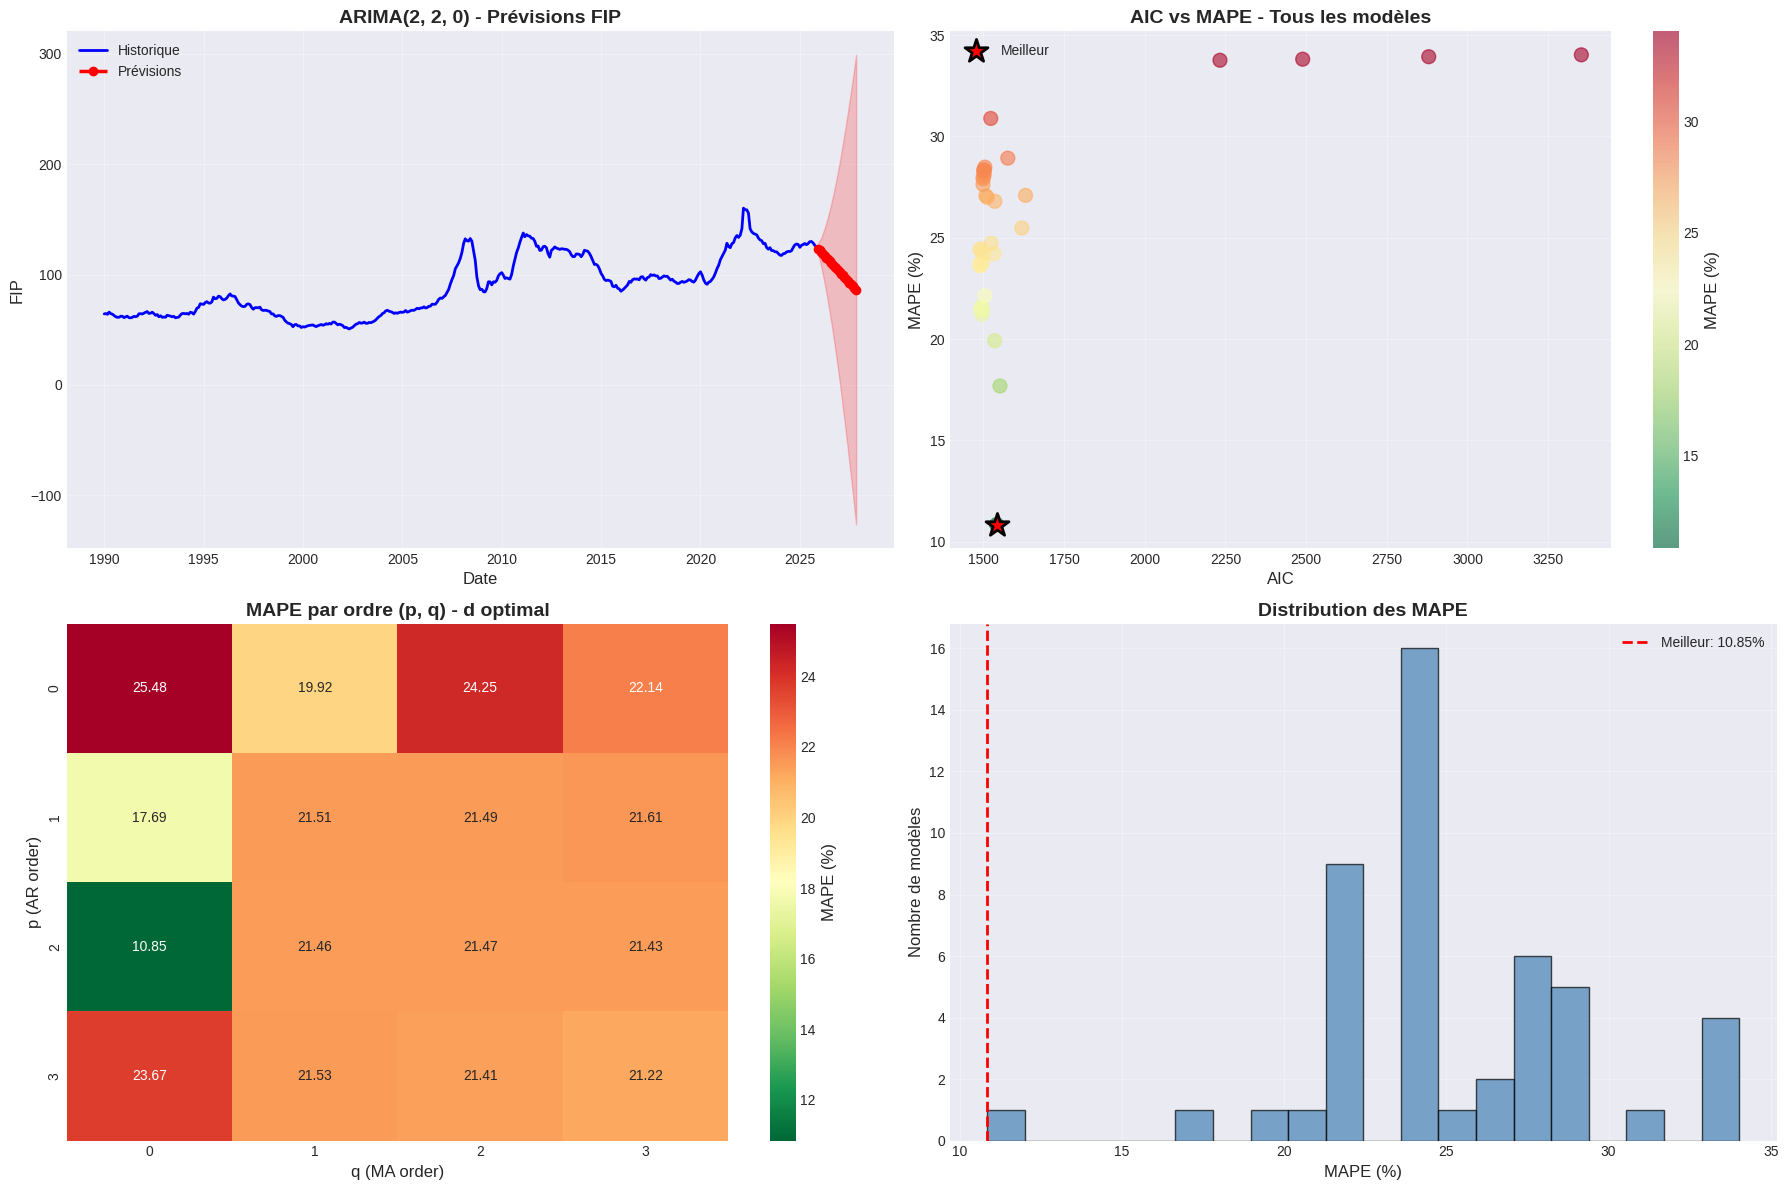


 Graphique sauvegardé : arima_optimization_results.png
 Résultats sauvegardés : arima_optimization_results.csv
 Prévisions sauvegardées : arima_forecasts_2025_2026.csv


In [87]:
##OPTIMISATION ARIMA - RECHERCHE DU MEILLEUR MODÈLE

TARGET_INDEX = 'FIP'

# Split train/test
train_size = int(len(dff1) * 0.85)
train_series = dff1[TARGET_INDEX].iloc[:train_size]
test_series = dff1[TARGET_INDEX].iloc[train_size:]

print(f"\n Données : Train={len(train_series)}, Test={len(test_series)}")

# Définir grille de recherche
p_values = range(0, 4)  # Ordre autorégressif
d_values = range(0, 3)  # Ordre de différenciation
q_values = range(0, 4)  # Ordre moyenne mobile

print(f"\n Grille de recherche : p={list(p_values)}, d={list(d_values)}, q={list(q_values)}")
print(f"   Total de combinaisons : {len(p_values) * len(d_values) * len(q_values)}")

# Recherche du meilleur modèle
best_aic = np.inf
best_bic = np.inf
best_order = None
best_mape = np.inf
results_list = []

print(f"\n Entraînement des modèles...")

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Entraîner modèle
                model = ARIMA(train_series, order=(p, d, q))
                fitted_model = model.fit()
                
                # Prédictions sur test
                forecast = fitted_model.forecast(steps=len(test_series))
                
                # Métriques
                aic = fitted_model.aic
                bic = fitted_model.bic
                mae = mean_absolute_error(test_series, forecast)
                mape = np.mean(np.abs((test_series - forecast) / test_series)) * 100
                
                results_list.append({
                    'p': p, 'd': d, 'q': q,
                    'AIC': aic, 'BIC': bic,
                    'MAE': mae, 'MAPE': mape
                })
                
                # Garder le meilleur selon MAPE
                if mape < best_mape:
                    best_mape = mape
                    best_order = (p, d, q)
                    best_aic = aic
                    best_bic = bic
                
            except Exception as e:
                continue

print(f"\n {len(results_list)} modèles entraînés avec succès")

# Convertir en DataFrame
results_df = pd.DataFrame(results_list).sort_values('MAPE')

print(f"\n TOP 10 MEILLEURS MODÈLES (par MAPE) :")
print("-" * 70)
print(results_df.head(10).to_string(index=False))

print(f"\n MEILLEUR MODÈLE :")
print(f"   Ordre : ARIMA{best_order}")
print(f"   MAPE  : {best_mape:.2f}%")
print(f"   AIC   : {best_aic:.2f}")
print(f"   BIC   : {best_bic:.2f}")

# Entraîner le meilleur modèle sur toutes les données
print(f"\n Entraînement du meilleur modèle sur données complètes...")
final_model = ARIMA(dff1[TARGET_INDEX], order=best_order)
final_fitted = final_model.fit()

# Prévisions futures (24 mois)
future_forecast = final_fitted.forecast(steps=24)
future_dates = pd.date_range(
    start=dff1['Date'].max() + pd.DateOffset(months=1),
    periods=24,
    freq='MS'
)

# Intervalles de confiance
forecast_result = final_fitted.get_forecast(steps=24)
confidence_intervals = forecast_result.conf_int()

print(f"\n Prévisions 2025-2026 (6 premiers mois) :")
for i in range(6):
    print(f"   {future_dates[i].strftime('%Y-%m')} : {future_forecast.iloc[i]:.2f} "
          f"[{confidence_intervals.iloc[i, 0]:.2f} - {confidence_intervals.iloc[i, 1]:.2f}]")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Graphique 1 : Historique + Prévisions
ax1 = axes[0, 0]
ax1.plot(dff1['Date'], dff1[TARGET_INDEX], label='Historique', color='blue', linewidth=2)
ax1.plot(future_dates, future_forecast, label='Prévisions', color='red', 
        linewidth=2.5, marker='o', linestyle='--')
ax1.fill_between(future_dates, confidence_intervals.iloc[:, 0], 
                 confidence_intervals.iloc[:, 1], alpha=0.2, color='red')
ax1.set_title(f'ARIMA{best_order} - Prévisions {TARGET_INDEX}', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel(TARGET_INDEX)
ax1.legend()
ax1.grid(alpha=0.3)

# Graphique 2 : Comparaison AIC vs MAPE
ax2 = axes[0, 1]
scatter = ax2.scatter(results_df['AIC'], results_df['MAPE'], 
                     c=results_df['MAPE'], cmap='RdYlGn_r', s=100, alpha=0.6)
ax2.scatter(best_aic, best_mape, color='red', s=300, marker='*', 
           edgecolors='black', linewidths=2, label='Meilleur')
ax2.set_xlabel('AIC', fontsize=12)
ax2.set_ylabel('MAPE (%)', fontsize=12)
ax2.set_title('AIC vs MAPE - Tous les modèles', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='MAPE (%)')

# Graphique 3 : Heatmap des MAPE par ordre
ax3 = axes[1, 0]
pivot_mape = results_df.pivot_table(index='p', columns='q', values='MAPE', aggfunc='min')
sns.heatmap(pivot_mape, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax3, cbar_kws={'label': 'MAPE (%)'})
ax3.set_title('MAPE par ordre (p, q) - d optimal', fontsize=14, fontweight='bold')
ax3.set_xlabel('q (MA order)')
ax3.set_ylabel('p (AR order)')

# Graphique 4 : Distribution des MAPE
ax4 = axes[1, 1]
ax4.hist(results_df['MAPE'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax4.axvline(best_mape, color='red', linestyle='--', linewidth=2, 
           label=f'Meilleur: {best_mape:.2f}%')
ax4.set_xlabel('MAPE (%)', fontsize=12)
ax4.set_ylabel('Nombre de modèles', fontsize=12)
ax4.set_title('Distribution des MAPE', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('arima_optimization_results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Graphique sauvegardé : arima_optimization_results.png")

# Sauvegarder résultats
results_df.to_csv('arima_optimization_results.csv', index=False)
print(f" Résultats sauvegardés : arima_optimization_results.csv")

# Sauvegarder prévisions
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_forecast,
    'Lower_CI': confidence_intervals.iloc[:, 0],
    'Upper_CI': confidence_intervals.iloc[:, 1]
})
forecast_df.to_csv('arima_forecasts_2025_2026.csv', index=False)
print(f" Prévisions sauvegardées : arima_forecasts_2025_2026.csv")


### Interprétation des Graphiques et Résultats ARIMA(2, 2, 0) 


Le processus d'optimisation a identifié que le meilleur modèle est un ARIMA(2, 2, 0), avec une erreur moyenne de prévision (MAPE) de 10,85 %. 
* 1. Graphique Supérieur Gauche : Historique et Prévisions FIP
     #### Description :
       * Le graphe affiche l'évolution historique de l'indice FIP (ligne bleue) de 1990 à fin 2025, et les prévisions pour 2026 (ligne rouge pointillée).
       * La zone ombrée représente l'intervalle de confiance à 95 % (la fourchette d'erreur probable).
     #### Interprétation :
       * Le FIP a connu une volatilité historique, avec un pic autour de 2008 et 2021.
       * Le modèle prédit une tendance baissière progressive pour l'indice en 2026.
     #### Point clé :
       * L'incertitude (la zone ombrée) s'élargit à mesure que l'on s'éloigne dans le temps (elle est fine en décembre 2025 et très large en mai 2026).
       * Le modèle est sûr de la tendance à court terme, mais beaucoup moins sur les valeurs exactes dans 6 mois.

         
* 2. Graphique Supérieur Droit : AIC vs MAPE
     #### Description :
       * Ce nuage de points compare la complexité (AIC, axe X) et la précision (MAPE, axe Y) de tous les 48 modèles testés.
     #### Interprétation :
       * Le modèle "idéal" se situe en bas à gauche (faible erreur, faible complexité).
       * L'étoile noire indique votre modèle gagnant ARIMA(2, 2, 0), qui n'a pas l'AIC le plus bas, mais qui a de loin le meilleur MAPE (10,85 %).
       * Il a trouvé le meilleur compromis pour prédire l'avenir.

         
* 3. Graphique Inférieur Gauche : Heatmap (MAPE par ordre)
     #### Description :
       * Une carte de chaleur montrant visuellement quels ordres \(p\) et \(q\) donnent les meilleurs résultats (zones vertes) pour le bon niveau de différenciation \(d=2\).
     #### Interprétation :
     * Les zones vertes se situent sur \(p=2,q=0\) (votre gagnant) et \(p=1,q=0\).
     * Cela indique que le FIP est majoritairement un processus Autorégressif (AR) ;
     * il dépend fortement de son propre passé récent plutôt que des erreurs passées (MA).

       
* 4. Graphique Inférieur Droit : Distribution des MAPE
     #### Description :
     * Un histogramme montrant la fréquence à laquelle les différents niveaux de MAPE sont atteints.
     * La ligne rouge indique le score du meilleur modèle.
     #### Interprétation :
     * La plupart des modèles ont un MAPE autour de 25 %.
     * Le meilleur modèle (10,85 %) est une valeur extrême à gauche, démontrant la pertinence de l'optimisation pour trouver une solution bien supérieure à la moyenne. 

### Interprétation Économique et pour les Investisseurs

Les résultats du modèle ARIMA(2, 2, 0) envoient un signal clair d'apaisement et de recul de l'inflation dans le secteur alimentaire pour le début de l'année 2026.

1. Tendance Clairement Baissière

    * Le Fait : L'indice FIP passe de 123,54 en décembre 2025 à 115,42 en mai 2026.
    * Conséquence Économique : C'est un signal de désinflation. Le coût des matières premières alimentaires diminue. Les transformateurs et distributeurs devraient voir leurs coûts d'approvisionnement baisser, ce qui pourrait (en théorie) se traduire par une stabilisation, voire une légère baisse des prix à la consommation d'ici l'été 2026.


2. Opportunités d'Investissement

    * Pour les investisseurs prudents : C'est le moment d'être prudent sur les investissements purement axés sur les matières premières (Commodities ETFs). La tendance baissière prédite suggère que les rendements seront faibles, voire négatifs sur ce secteur.
    * Pour les entreprises consommatrices : Les industriels (agroalimentaire, restaurants) devraient en profiter pour sécuriser leurs approvisionnements à des prix de marché avantageux.

3. Point de Vigilance sur l'Incertitude

    * Le Fait : La fourchette de prévision en mai 2026 va de 84,00 à 146,83.
    * Conséquence : Bien que la tendance centrale soit à la baisse, la volatilité historique du FIP reste élevée. Un investisseur doit être conscient du risque : si le marché subit un choc imprévu, l'indice pourrait remonter brutalement. L'utilisation d'outils de couverture (hedging) est recommandée.

* En résumé : Le modèle ARIMA prédit que la pression sur les prix alimentaires s'allège. C'est une bonne nouvelle pour les consommateurs et un signal de prudence pour les investisseurs exposés aux matières premières agricoles.

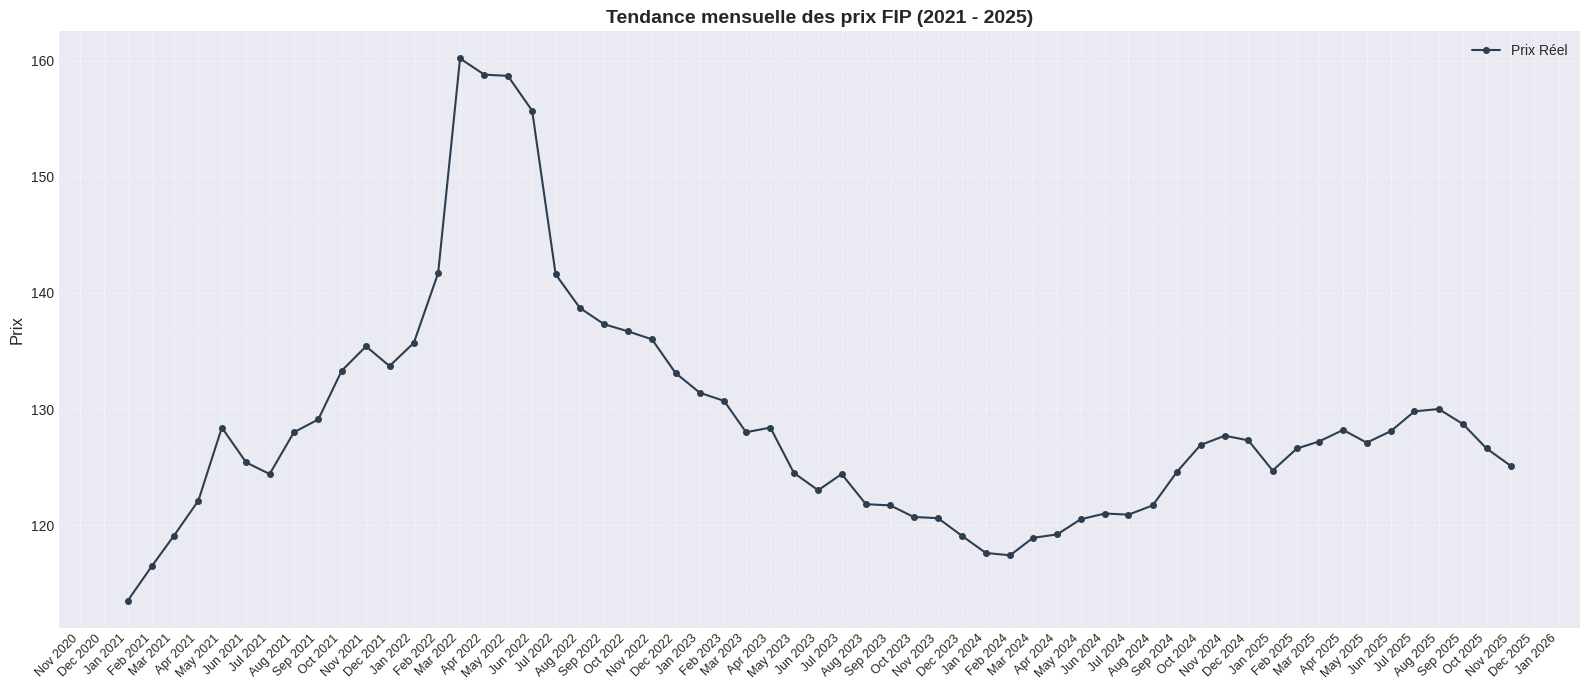

In [82]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Filtrage des données pour la période 2021-2025
# On prend les données réelles existantes + vos prévisions (future_dates/future_forecast)
mask_hist = (dff1['Date'] >= '2021-01-01') & (dff1['Date'] <= '2025-12-31')
data_2021_2025 = dff1.loc[mask_hist]

# 2. Création du graphique
plt.figure(figsize=(16, 7))

# Affichage de l'historique (jusqu'à la fin de vos données réelles)
plt.plot(data_2021_2025['Date'], data_2021_2025[TARGET_INDEX], 
         marker='o', linestyle='-', color='#2c3e50', label='Prix Réel', markersize=4)

# Si vous avez déjà généré 'future_dates' et 'future_forecast' (vos prévisions 2025)
# plt.plot(future_dates, future_forecast, marker='x', linestyle='--', color='red', label='Prévisions')

# 3. Configuration précise de l'axe X (Mois par Mois)
ax = plt.gca()

# Afficher une graduation pour CHAQUE mois
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 

# Format de la date : "Jan 2021"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotation pour la lisibilité
plt.xticks(rotation=45, ha='right', fontsize=9)

# 4. Habillage
plt.title(f'Tendance mensuelle des prix {TARGET_INDEX} (2021 - 2025)', fontsize=14, fontweight='bold')
plt.ylabel('Prix')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


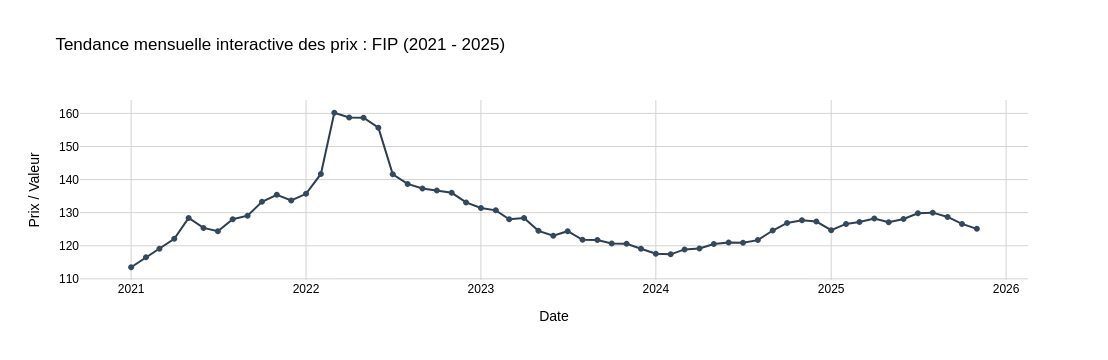

In [83]:
import plotly.express as px
import pandas as pd

# 1. Filtrage des données pour la période 2021-2025
dff1['Date'] = pd.to_datetime(dff1['Date'])
mask_hist = (dff1['Date'] >= '2021-01-01') & (dff1['Date'] <= '2025-12-31')
data_2021_2025 = dff1.loc[mask_hist].copy()

# Si nous avons des prévisions, nous pouvons les ajouter dans le dataframe pour Plotly
# En supposant que nous avons 'future_dates' et 'future_forecast' depuis le code ARIMA précédent:
# df_forecast = pd.DataFrame({'Date': future_dates, TARGET_INDEX: future_forecast, 'Type': 'Prévision'})
# data_2021_2025['Type'] = 'Réel'
# df_combined = pd.concat([data_2021_2025, df_forecast])


# 2. Création du graphique interactif avec Plotly Express
fig = px.line(
    data_2021_2025,
    x='Date',
    y=TARGET_INDEX,
    title=f'Tendance mensuelle interactive des prix : {TARGET_INDEX} (2021 - 2025)',
    markers=True, # Affiche les points sur la ligne
    # Configuration des informations affichées au survol
    hover_data={
        'Date': '|%b %Y', # Format de la date (Mois Année)
        TARGET_INDEX: ':.2f', # Format de la valeur à 2 décimales
    }
)

# Améliorations visuelles (optionnel)
fig.update_traces(line_color='#2c3e50', marker_color='#34495e')
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Prix / Valeur",
    legend_title="Type de Donnée",
    font=dict(
        family="Arial, sans-serif",
        size=12,
        color="black"
    ),
    plot_bgcolor='white'
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')


# 3. Affichage du graphique
fig.show()
